# Phase 3 — Battre le service statistique

## Objectifs

- Construire un jeu de classification de formes à partir de `comments` et `shape`.
- Définir les règles appliquées aux formes manquantes, aux fourre-tout, aux doublons de sens et aux classes trop rares.
- Créer une découpe entraînement / validation identique pour tous les modèles.
- Comparer une baseline majoritaire, un modèle linéaire TF-IDF et un modèle PyTorch.
- Afficher les courbes de perte d'entraînement et de validation du modèle PyTorch.


## 1. Imports

In [1]:
from pathlib import Path
import csv
import random
import re
import time
import urllib.request

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline as SklearnPipeline
from sklearn.preprocessing import LabelEncoder
from torch import nn
from torch.utils.data import DataLoader, Dataset


## 2. Configuration et reproductibilité

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cpu")

URL_DATA = (
    "https://raw.githubusercontent.com/planetsig/ufo-reports/master/"
    "csv-data/ufo-complete-geocoded-time-standardized.csv"
)

DATA_DIR = Path("../data")
OUTPUT_DIR = Path("../outputs")
PHASE3_DIR = OUTPUT_DIR / "phase_3_baseline_et_modele_pytorch"

DATA_DIR.mkdir(parents=True, exist_ok=True)
PHASE3_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = DATA_DIR / "releves_klaxo3.csv"

COLUMNS = [
    "datetime", "city", "state", "country", "shape",
    "duration_seconds", "duration_hours_min", "comments",
    "date_posted", "latitude", "longitude",
]

TEST_SIZE = 0.20
SEUIL_MIN_CLASSE = 5
BATCH_SIZE = 128
EMBEDDING_DIM = 96
HIDDEN_DIM = 128
DROPOUT = 0.30
LEARNING_RATE = 0.003
WEIGHT_DECAY = 0.0001
N_EPOCHS = 20
PATIENCE = 4


## 3. Téléchargement de la transmission

In [3]:
if not DATA_PATH.exists():
    print("Téléchargement du fichier...")
    urllib.request.urlretrieve(URL_DATA, DATA_PATH)
    print("Téléchargement terminé.")
else:
    print(f"Fichier déjà disponible : {DATA_PATH}")


Fichier déjà disponible : ..\data\releves_klaxo3.csv


## 4. Chargement robuste des relevés

In [4]:
lignes_valides = []
lignes_problemes = []

with open(DATA_PATH, "r", encoding="utf-8", errors="replace", newline="") as f:
    reader = csv.reader(f)

    for numero_ligne, row in enumerate(reader, start=1):
        if len(row) == len(COLUMNS):
            lignes_valides.append(row)
        else:
            lignes_problemes.append({
                "numero_ligne": numero_ligne,
                "nombre_champs": len(row),
                "contenu": row,
            })

df = pd.DataFrame(lignes_valides, columns=COLUMNS)

print(f"Lignes chargées : {len(df)}")
print(f"Lignes mises à part : {len(lignes_problemes)}")


Lignes chargées : 88679
Lignes mises à part : 196


## 5. Préparation de la cible et règles de sélection

Règles retenues :

- Les relevés sans forme sont exclus car la cible supervisée est inconnue.
- `unknown` et `other` sont exclus car ce sont des catégories fourre-tout.
- `round` est fusionné dans `circle`.
- `changed` est fusionné dans `changing`.
- Les classes ayant moins de cinq relevés sont exclues de cette phase : elles ne peuvent pas être réparties et évaluées de manière fiable avec une validation stratifiée.


In [5]:
df["comments_clean"] = (
    df["comments"]
    .fillna("")
    .astype(str)
    .str.strip()
)

df["shape_clean"] = (
    df["shape"]
    .fillna("")
    .astype(str)
    .str.lower()
    .str.strip()
)

df["shape_model"] = df["shape_clean"].replace({
    "round": "circle",
    "changed": "changing",
})

masque_forme_manquante = df["shape_clean"].eq("")
masque_fourre_tout = df["shape_model"].isin(["unknown", "other"])
masque_commentaire_vide = df["comments_clean"].eq("")

df_avant_filtre_classes_rares = df.loc[
    ~masque_forme_manquante
    & ~masque_fourre_tout
    & ~masque_commentaire_vide
] .copy()

compte_classes_avant_filtre = (
    df_avant_filtre_classes_rares["shape_model"]
    .value_counts()
)

classes_rares_exclues = compte_classes_avant_filtre.loc[
    compte_classes_avant_filtre < SEUIL_MIN_CLASSE
]

classes_conservees = compte_classes_avant_filtre.loc[
    compte_classes_avant_filtre >= SEUIL_MIN_CLASSE
] .index

df_modele = df_avant_filtre_classes_rares.loc[
    df_avant_filtre_classes_rares["shape_model"].isin(classes_conservees)
] .copy()

print(f"Lignes sans forme écartées : {int(masque_forme_manquante.sum())}")
print(f"Lignes unknown / other écartées : {int(masque_fourre_tout.sum())}")
print(f"Lignes sans commentaire écartées : {int(masque_commentaire_vide.sum())}")
print(f"Seuil minimal par classe : {SEUIL_MIN_CLASSE}")
print(f"Classes rares exclues : {classes_rares_exclues.to_dict()}")
print(f"Relevés gardés : {len(df_modele)}")
print(f"Nombre de classes retenues : {df_modele['shape_model'].nunique()}")


Lignes sans forme écartées : 2922
Lignes unknown / other écartées : 12566
Lignes sans commentaire écartées : 35
Seuil minimal par classe : 5
Classes rares exclues : {'crescent': 2, 'pyramid': 1, 'flare': 1, 'hexagon': 1, 'dome': 1}
Relevés gardés : 73177
Nombre de classes retenues : 20


## 6. Distribution finale des classes

In [6]:
distribution_classes = (
    df_modele["shape_model"]
    .value_counts()
    .rename_axis("forme")
    .reset_index(name="nombre_releves")
)

distribution_classes


,forme,nombre_releves
0,light,17870
1,triangle,8488
2,circle,8454
3,fireball,6562
4,disk,6005
5,sphere,5754
6,oval,4117
7,formation,2657
8,cigar,2241
9,changing,2141


## 7. Découpage entraînement / validation

La découpe est stratifiée : chaque classe retenue est présente dans les deux ensembles. Les trois modèles de la phase utilisent exactement cette même séparation.


In [7]:
X = df_modele["comments_clean"].copy()
y = df_modele["shape_model"].copy()

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y,
)

print(f"Taille train : {len(X_train)}")
print(f"Taille validation : {len(X_val)}")
print(f"Classes train : {y_train.nunique()}")
print(f"Classes validation : {y_val.nunique()}")


Taille train : 58541
Taille validation : 14636
Classes train : 20
Classes validation : 20


## 8. Baseline majoritaire

In [8]:
classe_majoritaire = y_train.value_counts().idxmax()
predictions_majoritaires = np.repeat(classe_majoritaire, len(y_val))
accuracy_majoritaire = accuracy_score(y_val, predictions_majoritaires)

print(f"Classe majoritaire : {classe_majoritaire}")
print(f"Accuracy baseline majoritaire : {accuracy_majoritaire:.2%}")


Classe majoritaire : light
Accuracy baseline majoritaire : 24.42%


## 9. Baseline statistique : TF-IDF et régression logistique

In [9]:
modele_lineaire = SklearnPipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                min_df=2,
                max_features=20_000,
                ngram_range=(1, 2),
                sublinear_tf=True,
            ),
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=500,
                class_weight="balanced",
                random_state=SEED,
            ),
        ),
    ]
)

debut_lineaire = time.perf_counter()
modele_lineaire.fit(X_train, y_train)
temps_lineaire = time.perf_counter() - debut_lineaire

predictions_lineaires = modele_lineaire.predict(X_val)
accuracy_lineaire = accuracy_score(y_val, predictions_lineaires)

print(f"Accuracy modèle linéaire : {accuracy_lineaire:.2%}")
print(f"Temps d'entraînement linéaire : {temps_lineaire:.2f} secondes")


Accuracy modèle linéaire : 49.11%
Temps d'entraînement linéaire : 32.78 secondes


## 10. Tokenisation et vocabulaire PyTorch

Le vocabulaire est construit à partir du train seulement. Les mots absents du train sont codés `<UNK>` dans la validation.


In [10]:
def tokenizer(texte):
    return re.findall(r"[a-z0-9]+", str(texte).lower())

vocabulaire = {"<PAD>": 0, "<UNK>": 1}

for texte in X_train:
    for token in tokenizer(texte):
        if token not in vocabulaire:
            vocabulaire[token] = len(vocabulaire)

label_encoder = LabelEncoder()
y_train_ids = label_encoder.fit_transform(y_train)
y_val_ids = label_encoder.transform(y_val)

print(f"Taille vocabulaire train : {len(vocabulaire)}")
print(f"Classes : {list(label_encoder.classes_)}")


Taille vocabulaire train : 25555
Classes : ['changing', 'chevron', 'cigar', 'circle', 'cone', 'cross', 'cylinder', 'delta', 'diamond', 'disk', 'egg', 'fireball', 'flash', 'formation', 'light', 'oval', 'rectangle', 'sphere', 'teardrop', 'triangle']


## 11. Dataset et fonction de regroupement PyTorch

In [11]:
class DatasetTextes(Dataset):
    def __init__(self, textes, labels, vocabulaire):
        self.textes = list(textes)
        self.labels = list(labels)
        self.vocabulaire = vocabulaire

    def __len__(self):
        return len(self.textes)

    def __getitem__(self, index):
        tokens = tokenizer(self.textes[index])
        ids = [
            self.vocabulaire.get(token, self.vocabulaire["<UNK>"])
            for token in tokens
        ]

        if len(ids) == 0:
            ids = [self.vocabulaire["<UNK>"]]

        return torch.tensor(ids, dtype=torch.long), int(self.labels[index])

def collate_embedding_bag(batch):
    offsets = [0]
    tokens_concat = []
    labels_batch = []

    for tokens, label in batch:
        tokens_concat.extend(tokens.tolist())
        labels_batch.append(label)
        offsets.append(offsets[-1] + len(tokens))

    return (
        torch.tensor(tokens_concat, dtype=torch.long),
        torch.tensor(offsets[:-1], dtype=torch.long),
        torch.tensor(labels_batch, dtype=torch.long),
    )

dataset_train = DatasetTextes(X_train, y_train_ids, vocabulaire)
dataset_val = DatasetTextes(X_val, y_val_ids, vocabulaire)

loader_train = DataLoader(
    dataset_train,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_embedding_bag,
)

loader_val = DataLoader(
    dataset_val,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_embedding_bag,
)


## 12. Modèle PyTorch : EmbeddingBag et réseau dense

In [12]:
class ClassifieurPyTorch(nn.Module):
    def __init__(self, taille_vocabulaire, nombre_classes):
        super().__init__()
        self.embedding = nn.EmbeddingBag(
            taille_vocabulaire,
            EMBEDDING_DIM,
            mode="mean",
        )
        self.reseau = nn.Sequential(
            nn.Linear(EMBEDDING_DIM, HIDDEN_DIM),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
            nn.Linear(HIDDEN_DIM, nombre_classes),
        )

    def forward(self, tokens, offsets):
        representation = self.embedding(tokens, offsets)
        return self.reseau(representation)

modele_pytorch = ClassifieurPyTorch(
    taille_vocabulaire=len(vocabulaire),
    nombre_classes=len(label_encoder.classes_),
).to(DEVICE)

modele_pytorch


ClassifieurPyTorch(
  (embedding): EmbeddingBag(25555, 96, mode='mean')
  (reseau): Sequential(
    (0): Linear(in_features=96, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=20, bias=True)
  )
)

## 13. Fonctions d'entraînement et d'évaluation

In [13]:
def une_epoque_train(modele, loader, optimiseur, fonction_perte):
    modele.train()
    perte_totale = 0.0
    nombre_exemples = 0

    for tokens, offsets, labels in loader:
        tokens = tokens.to(DEVICE)
        offsets = offsets.to(DEVICE)
        labels = labels.to(DEVICE)

        optimiseur.zero_grad()
        logits = modele(tokens, offsets)
        perte = fonction_perte(logits, labels)
        perte.backward()
        optimiseur.step()

        perte_totale += perte.item() * len(labels)
        nombre_exemples += len(labels)

    return perte_totale / nombre_exemples

def evaluer_modele(modele, loader, fonction_perte):
    modele.eval()
    perte_totale = 0.0
    nombre_exemples = 0
    predictions = []
    labels_reels = []

    with torch.no_grad():
        for tokens, offsets, labels in loader:
            tokens = tokens.to(DEVICE)
            offsets = offsets.to(DEVICE)
            labels = labels.to(DEVICE)

            logits = modele(tokens, offsets)
            perte = fonction_perte(logits, labels)
            pred = logits.argmax(dim=1)

            perte_totale += perte.item() * len(labels)
            nombre_exemples += len(labels)
            predictions.extend(pred.cpu().tolist())
            labels_reels.extend(labels.cpu().tolist())

    accuracy = accuracy_score(labels_reels, predictions)

    return perte_totale / nombre_exemples, accuracy, labels_reels, predictions


## 14. Entraînement du modèle PyTorch

In [14]:
fonction_perte = nn.CrossEntropyLoss()
optimiseur = torch.optim.AdamW(
    modele_pytorch.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

historique = {
    "epoch": [],
    "train_loss": [],
    "val_loss": [],
    "val_accuracy": [],
}

meilleure_perte_val = float("inf")
meilleur_etat = None
epochs_sans_amelioration = 0

debut_pytorch = time.perf_counter()

for epoch in range(1, N_EPOCHS + 1):
    perte_train = une_epoque_train(
        modele_pytorch, loader_train, optimiseur, fonction_perte
    )

    perte_val, accuracy_val, _, _ = evaluer_modele(
        modele_pytorch, loader_val, fonction_perte
    )

    historique["epoch"].append(epoch)
    historique["train_loss"].append(perte_train)
    historique["val_loss"].append(perte_val)
    historique["val_accuracy"].append(accuracy_val)

    print(
        f"Epoch {epoch:02d} | train loss={perte_train:.4f} | "
        f"val loss={perte_val:.4f} | val accuracy={accuracy_val:.2%}"
    )

    if perte_val < meilleure_perte_val:
        meilleure_perte_val = perte_val
        meilleur_etat = {
            nom: tenseur.cpu().clone()
            for nom, tenseur in modele_pytorch.state_dict().items()
        }
        epochs_sans_amelioration = 0
    else:
        epochs_sans_amelioration += 1

    if epochs_sans_amelioration >= PATIENCE:
        print("Arrêt anticipé : absence d'amélioration de la validation.")
        break

temps_pytorch = time.perf_counter() - debut_pytorch
modele_pytorch.load_state_dict(meilleur_etat)

print(f"Temps entraînement PyTorch : {temps_pytorch:.2f} secondes")


Epoch 01 | train loss=2.0155 | val loss=1.7910 | val accuracy=49.23%
Epoch 02 | train loss=1.6905 | val loss=1.7082 | val accuracy=52.75%
Epoch 03 | train loss=1.5417 | val loss=1.6935 | val accuracy=53.14%
Epoch 04 | train loss=1.4234 | val loss=1.7122 | val accuracy=53.55%
Epoch 05 | train loss=1.3163 | val loss=1.7547 | val accuracy=53.59%
Epoch 06 | train loss=1.2159 | val loss=1.8239 | val accuracy=53.42%
Epoch 07 | train loss=1.1254 | val loss=1.9290 | val accuracy=52.71%
Arrêt anticipé : absence d'amélioration de la validation.
Temps entraînement PyTorch : 133.35 secondes


## 15. Courbes de perte entraînement et validation

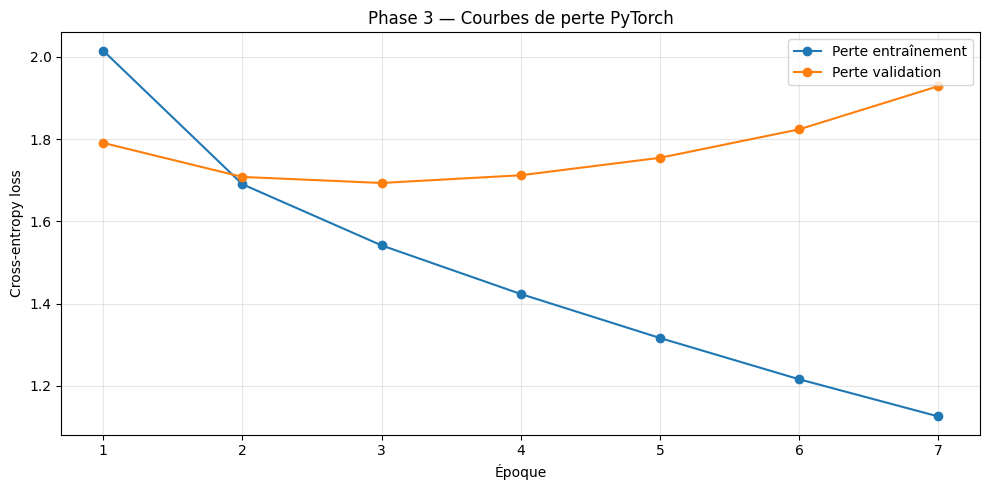

In [15]:
plt.figure(figsize=(10, 5))
plt.plot(
    historique["epoch"], historique["train_loss"],
    marker="o", label="Perte entraînement"
)
plt.plot(
    historique["epoch"], historique["val_loss"],
    marker="o", label="Perte validation"
)
plt.title("Phase 3 — Courbes de perte PyTorch")
plt.xlabel("Époque")
plt.ylabel("Cross-entropy loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(PHASE3_DIR / "courbes_perte_pytorch.png", dpi=150)
plt.show()


## 16. Évaluation finale du modèle PyTorch

In [16]:
perte_val_finale, accuracy_pytorch, labels_val_finales, predictions_pytorch_ids = evaluer_modele(
    modele_pytorch, loader_val, fonction_perte
)

predictions_pytorch = label_encoder.inverse_transform(predictions_pytorch_ids)

print(f"Accuracy PyTorch : {accuracy_pytorch:.2%}")
print(f"Perte validation finale : {perte_val_finale:.4f}")

print(classification_report(y_val, predictions_pytorch, zero_division=0))


Accuracy PyTorch : 53.14%
Perte validation finale : 1.6935
              precision    recall  f1-score   support

    changing       0.42      0.16      0.23       428
     chevron       0.74      0.33      0.46       201
       cigar       0.82      0.48      0.60       448
      circle       0.36      0.36      0.36      1691
        cone       0.92      0.16      0.28        73
       cross       1.00      0.08      0.14        53
    cylinder       0.62      0.40      0.49       276
       delta       0.00      0.00      0.00         2
     diamond       0.76      0.45      0.57       262
        disk       0.44      0.60      0.51      1201
         egg       0.87      0.31      0.46       169
    fireball       0.65      0.57      0.61      1313
       flash       0.62      0.27      0.37       294
   formation       0.43      0.27      0.33       531
       light       0.51      0.76      0.61      3574
        oval       0.53      0.34      0.42       824
   rectangle       0.8

## 17. Comparaison des trois modèles

In [17]:
resultats_comparaison = pd.DataFrame([
    {
        "modele": "Baseline majoritaire",
        "accuracy_validation": accuracy_majoritaire,
        "temps_entrainement_secondes": 0.0,
    },
    {
        "modele": "TF-IDF + régression logistique",
        "accuracy_validation": accuracy_lineaire,
        "temps_entrainement_secondes": temps_lineaire,
    },
    {
        "modele": "PyTorch EmbeddingBag + MLP",
        "accuracy_validation": accuracy_pytorch,
        "temps_entrainement_secondes": temps_pytorch,
    },
])

resultats_comparaison


,modele,accuracy_validation,temps_entrainement_secondes
0,Baseline majoritaire,0.244192,0.000000
1,TF-IDF + régression logistique,0.491118,32.781835
2,PyTorch EmbeddingBag + MLP,0.531429,133.349202


## 18. Vérification de l'objectif

In [18]:
print(f"Baseline majoritaire : {accuracy_majoritaire:.2%}")
print(f"Modèle linéaire : {accuracy_lineaire:.2%}")
print(f"Modèle PyTorch : {accuracy_pytorch:.2%}")

if accuracy_pytorch > accuracy_lineaire:
    print("Objectif atteint : PyTorch dépasse le modèle linéaire.")
else:
    print("Objectif non atteint : améliorer le modèle PyTorch avant de finaliser la phase.")


Baseline majoritaire : 24.42%
Modèle linéaire : 49.11%
Modèle PyTorch : 53.14%
Objectif atteint : PyTorch dépasse le modèle linéaire.


## 19. Export des résultats

In [19]:
distribution_classes.to_csv(
    PHASE3_DIR / "distribution_classes_retenues.csv", index=False
)

classes_rares_exclues.rename("nombre_releves").rename_axis("forme").reset_index().to_csv(
    PHASE3_DIR / "classes_rares_exclues.csv", index=False
)

pd.DataFrame(historique).to_csv(
    PHASE3_DIR / "historique_pertes_pytorch.csv", index=False
)

resultats_comparaison.to_csv(
    PHASE3_DIR / "comparaison_modeles.csv", index=False
)

rapport_classes_pytorch = classification_report(
    y_val, predictions_pytorch, output_dict=True, zero_division=0
)

pd.DataFrame(rapport_classes_pytorch).transpose().to_csv(
    PHASE3_DIR / "scores_par_classe_pytorch.csv", index=True
)

resume_phase3 = pd.DataFrame([
    {
        "nombre_releves_total": len(df),
        "formes_manquantes_exclues": int(masque_forme_manquante.sum()),
        "fourre_tout_exclus": int(masque_fourre_tout.sum()),
        "commentaires_vides_exclus": int(masque_commentaire_vide.sum()),
        "seuil_min_classe": SEUIL_MIN_CLASSE,
        "classes_rares_exclues": ", ".join(classes_rares_exclues.index.tolist()),
        "nombre_releves_gardes": len(df_modele),
        "nombre_classes_retenues": len(label_encoder.classes_),
        "classes_retenues": ", ".join(label_encoder.classes_),
        "taille_train": len(X_train),
        "taille_validation": len(X_val),
        "classe_majoritaire": classe_majoritaire,
        "accuracy_majoritaire": accuracy_majoritaire,
        "accuracy_lineaire": accuracy_lineaire,
        "accuracy_pytorch": accuracy_pytorch,
        "epochs_executees": len(historique["epoch"]),
        "temps_lineaire_secondes": temps_lineaire,
        "temps_pytorch_secondes": temps_pytorch,
    }
])

resume_phase3.to_csv(
    PHASE3_DIR / "resume_phase3.csv", index=False
)

torch.save(
    {
        "model_state_dict": modele_pytorch.state_dict(),
        "vocabulaire": vocabulaire,
        "classes": list(label_encoder.classes_),
        "hyperparametres": {
            "embedding_dim": EMBEDDING_DIM,
            "hidden_dim": HIDDEN_DIM,
            "dropout": DROPOUT,
        },
    },
    PHASE3_DIR / "modele_pytorch_phase3.pt",
)

print("Fichiers exportés dans :")
print(PHASE3_DIR)


Fichiers exportés dans :
..\outputs\phase_3_baseline_et_modele_pytorch
